In [3]:
import urllib.request

url = "https://raw.githubusercontent.com/liyaguang/DCRNN/master/data/sensor_graph/graph_sensor_locations.csv"

urllib.request.urlretrieve(url, "graph_sensor_locations.csv")

print("Download complete")

Download complete


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [5]:
# 1. Load Sensor Locations
loc=pd.read_csv("/content/graph_sensor_locations.csv")


print("Location dataset shape:", loc.shape)
print(loc.head())

Location dataset shape: (207, 4)
   index  sensor_id  latitude  longitude
0      0     773869  34.15497 -118.31829
1      1     767541  34.11621 -118.23799
2      2     767542  34.11641 -118.23819
3      3     717447  34.07248 -118.26772
4      4     717446  34.07142 -118.26572


In [6]:
# 2. Visualize Sensors

m = folium.Map(
    location=[loc['latitude'].mean(), loc['longitude'].mean()],
    zoom_start=10
)

for _, row in loc.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3
    ).add_to(m)

m

In [7]:
# 3. Extract Coordinates


coords = loc[['latitude','longitude']].values

num_sensors = coords.shape[0]

print("Number of sensors:", num_sensors)


Number of sensors: 207


In [8]:
# 4. Haversine Distance

def haversine(lat1, lon1, lat2, lon2):

    R = 6371  # Earth radius (km)

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))

    return R * c


In [9]:
# 5. Build Distance Matrix

distance_matrix = np.zeros((num_sensors, num_sensors))

for i in range(num_sensors):
    for j in range(num_sensors):

        lat1, lon1 = coords[i]
        lat2, lon2 = coords[j]

        distance_matrix[i, j] = haversine(lat1, lon1, lat2, lon2)

print("Distance matrix shape:", distance_matrix.shape)

np.save("distance_matrix_full.npy", distance_matrix)



Distance matrix shape: (207, 207)


In [10]:
# 6. Build Adjacency Matrix


sigma = distance_matrix.std()

adjacency = np.exp(-(distance_matrix**2) / (sigma**2))

distance_threshold = 5   # km

adjacency[distance_matrix > distance_threshold] = 0

np.fill_diagonal(adjacency, 0)

print("Adjacency matrix shape:", adjacency.shape)


Adjacency matrix shape: (207, 207)


In [11]:
# 7. Normalize Adjacency

A = adjacency
I = np.eye(A.shape[0])

A_hat = A + I

D = np.diag(np.sum(A_hat, axis=1))

D_inv_sqrt = np.linalg.inv(np.sqrt(D))

adjacency = D_inv_sqrt @ A_hat @ D_inv_sqrt


np.save("adjacency_full.npy", adjacency)


In [12]:
# 8. Sanity Check
# ==========================

neighbors = (adjacency > 0).sum(axis=1)

print("Average neighbors:", neighbors.mean())


Average neighbors: 37.42512077294686


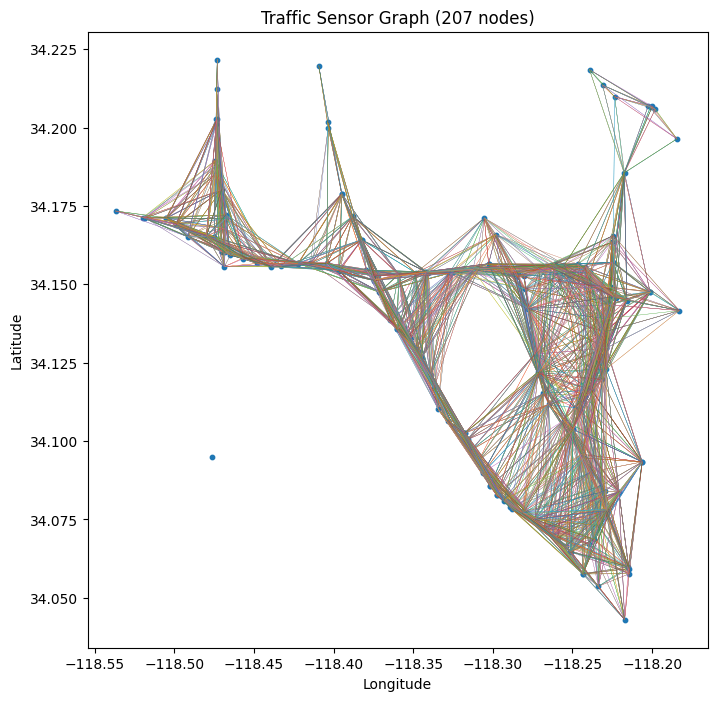

In [13]:

# 9. Graph Visualization


plt.figure(figsize=(8,8))

plt.scatter(coords[:,1], coords[:,0], s=10)

for i in range(num_sensors):
    for j in range(num_sensors):

        if adjacency[i,j] > 0:

            plt.plot(
                [coords[i,1], coords[j,1]],
                [coords[i,0], coords[j,0]],
                linewidth=0.2
            )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Traffic Sensor Graph (207 nodes)")

plt.show()

In [15]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')

Mounted at /content/drive


['git and git hub.pdf',
 'data science methodoiology.pdf',
 'ec council.pdf',
 'database and sql.pdf',
 'data anlaysis with python.pdf',
 'data vissulation with python.pdf',
 'Colab Notebooks',
 'DSA - Real World Examples.pdf',
 'DSA PATTERNS.pdf',
 'IMPORTANT DSA cheatsheet.pdf',
 'Document 25_removed.pdf',
 'pneumonia_model.h5',
 'lda_model_1.pkl',
 'vectorizer_1.pkl',
 'QA_Project',
 'Euducation_Loan.ipynb',
 'STGCN_Project']

In [16]:
!mv *.npy /content/drive/MyDrive/STGCN_Project/
!mv *.pkl /content/drive/MyDrive/STGCN_Project/
!mv *.pth /content/drive/MyDrive/STGCN_Project/

mv: cannot stat '*.pkl': No such file or directory
mv: cannot stat '*.pth': No such file or directory
